# Equilibrium Propagation Demonstration

This notebook focuses on the **Equilibrium Propagation (EqProp)** model for hippocampal sequence learning. It demonstrates how EqProp acts as a continuous attractor to stabilize trajectory recall, especially in the presence of multimodal context and overlapping spatial paths.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from memval.generators.temporal import PureToneSequenceGenerator
from memval.encoders.audio import PureToneEncoder
from memval.generators.t_maze import TMazeGenerator
from memval.encoders.spatial import PlaceCellEncoder
from memval.models.baselines.dg_eqprop import DGEqPropSequenceNetwork

sns.set_theme(style='darkgrid')
from memval.utils.visualization import plot_imprinted_coordinate


## 1. Setup T-Maze and Encoders
We use the standard T-maze setup with a central stem that splits into left and right arms.

In [2]:
seq_len = 30
tmaze_gen = TMazeGenerator(seed=42)
tmaze_left = tmaze_gen.generate(n_sequences=1, sequence_length=seq_len, turn_direction='left')[0]
tmaze_right = tmaze_gen.generate(n_sequences=1, sequence_length=seq_len, turn_direction='right')[0]

prompt_len = int(seq_len * 0.1)

## 2. Basic Sequence Completion
Before tackling disambiguation, let's verify that EqProp can perform simple pattern completion on a single T-maze trajectory.

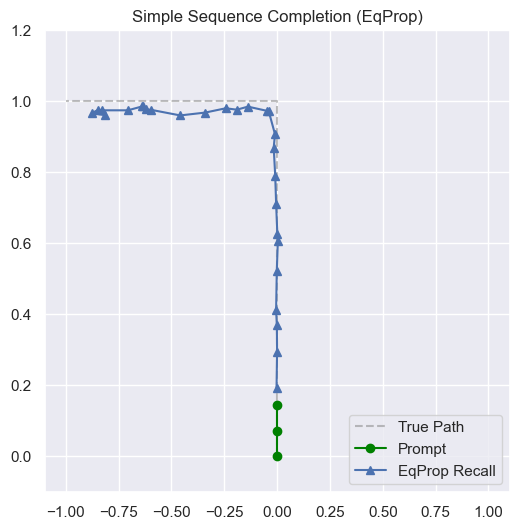

<Figure size 600x500 with 0 Axes>

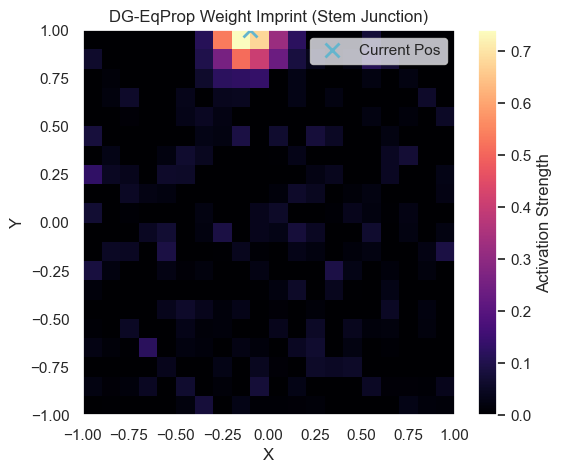

In [3]:
# --- 1. Train EqProp for simple pattern completion ---
pc_encoder = PlaceCellEncoder(seed=42)
pc_left = pc_encoder.encode(tmaze_left)
pc_right = pc_encoder.encode(tmaze_right)

model_completion = DGEqPropSequenceNetwork(
    n_features=pc_encoder.n_cells,
    n_context=10, # Default structural clock
    n_dg=1000,
    sparsity=0.05,
    n_hidden=128,
    n_epochs=100,
    learning_rate=0.05,
    seed=42
)

model_completion.fit_sequence(pc_right)
model_completion.fit_sequence(pc_left)

# --- 2. Recall from short prompt ---
prompt_pc = pc_left[:prompt_len]
model_completion.reset_context()

recon_pc = model_completion.recall(prompt_pc, length=seq_len - prompt_len)

# --- 3. Decode and Visualize ---
recon_path = pc_encoder.decode(recon_pc, power=4)
prompt_path = tmaze_left[:prompt_len]

plt.figure(figsize=(6, 6))
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], "--", color="gray", alpha=0.5, label="True Path")
plt.plot(prompt_path[:, 0], prompt_path[:, 1], "-o", color="green", label="Prompt")
plt.plot(recon_path[:, 0], recon_path[:, 1], "-b^", label="EqProp Recall")
plt.xlim(-1.1, 1.1); plt.ylim(-0.1, 1.2)
plt.title("Simple Sequence Completion (EqProp)")
plt.legend(loc="lower right")
plt.show()

# --- 4. Visualize Weight Imprint ---
plt.figure(figsize=(6, 5))
# Visualize what the network 'expects' at the T-maze junction
plot_imprinted_coordinate(model_completion, pc_encoder, coordinate=[-0.1, 1.0])
plt.title("DG-EqProp Weight Imprint (Stem Junction)")
plt.show()


## 3. The Un-opinionated Auto-Regressive Approach (And Why it Fails)
Following a more general machine learning framework, we can concatenate the decaying auditory trace directly into the sequence tensor `(Time, Features)`, dropping the explicit `context_data` argument entirely.

In this purely auto-regressive paradigm, the network must *predict* the decaying tone at each step alongside the spatial movement.

As we will see below, this leads to **Drift and Catastrophic Interference**. Because the tone is no longer a stable clamped external signal (exogenous) but a predicted internal variable (endogenous), small prediction errors accumulate at each step. By the time the agent reaches the decision junction, the predicted traces for both paths converge, destroying pattern separability!

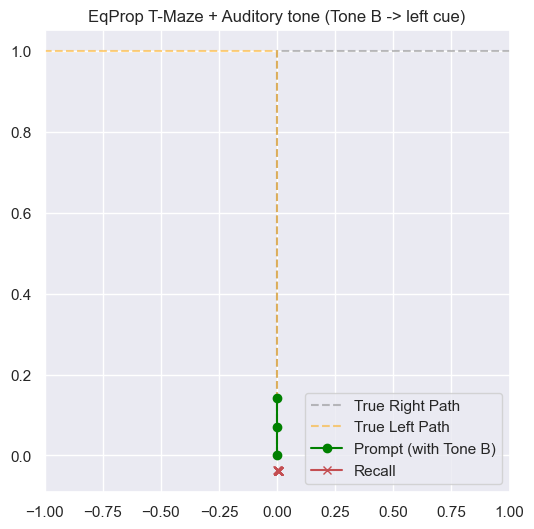

In [ ]:
# --- 1. Generate Temporal Traces for the Auditory Cue ---
# def add_temporal_trace(sequence: np.ndarray, decay_rate: float = 0.9) -> np.ndarray:
#     trace_seq = np.zeros_like(sequence)
#     trace_seq[0] = sequence[0]
#     for t in range(1, len(sequence)):
#         trace_seq[t] = sequence[t] + decay_rate * trace_seq[t-1]
#     return trace_seq

tone_a_traced = np.full((seq_len, 1), 5.0)
tone_b_traced = np.full((seq_len, 1), -5.0)

# --- 2. Encode Modalities and Concatenate ---
pt_encoder = PureToneEncoder(n_bins=50, min_freq=-5.0, max_freq=5.0, seed=42)

pc_left = pc_encoder.encode(tmaze_left)
pc_right = pc_encoder.encode(tmaze_right)

pt_left = pt_encoder.encode(tone_b_traced)
pt_right = pt_encoder.encode(tone_a_traced)

joint_left = np.concatenate([pc_left, pt_left], axis=-1)
joint_right = np.concatenate([pc_right, pt_right], axis=-1)

# --- 3. Train Dentate Gyrus without Context ---
total_features = pc_encoder.n_cells + pt_encoder.n_cells
model_dg_disambig = DGEqPropSequenceNetwork(
    n_features=total_features,
    n_context=10,  # Auto-generates standard structural clock
    n_dg=1000,
    sparsity=0.05,
    n_hidden=128,
    n_epochs=100, 
    learning_rate=0.05,
    seed=42
)

# NO explicit context passed!
model_dg_disambig.fit_sequence(joint_right)
model_dg_disambig.fit_sequence(joint_left)

# --- 4. Evaluate and Recall ---
prompt_path_left = joint_right[:prompt_len]
model_dg_disambig.reset_context()
# Network must predict the future encoded tone trace itself!
recon_joint_left = model_dg_disambig.recall(
    prompt_path_left, 
    length=seq_len - prompt_len
)

# --- 5. Decode back to 2D ---
recon_pc_left = recon_joint_left[:, :pc_encoder.n_cells]
reconstructed_path_left = pc_encoder.decode(recon_pc_left, power=4)

# --- 6. Visualize Failure ---
prompt_path = tmaze_left[:prompt_len]

plt.figure(figsize=(6, 6))
plt.plot(tmaze_right[:, 0], tmaze_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], '--', color='orange', alpha=0.5, label='True Left Path')
plt.plot(prompt_path[:, 0], prompt_path[:, 1], '-o', color='green', label='Prompt (with Tone B)')
plt.plot(reconstructed_path_left[:, 0], reconstructed_path_left[:, 1], '-rx', label='Recall')
plt.xlim(-1.0, 1.0)
plt.title('EqProp T-Maze + Auditory tone (Tone B -> left cue)')
plt.legend(loc='lower right')
plt.show()

## 4. Active Navigation (Clamped Context)
Now, let's model the biological reality of **Active Navigation**. Here, the Lateral Entorhinal Cortex (LEC) is continuously feeding the decaying auditory trace into the Dentate Gyrus and CA3. From the perspective of the network, it does not need to predict the tone; the tone is an exogenous, clamped boundary condition.

By explicitly passing the auditory trace as `context_data` during fitting and `prompt_context` during recall, the Dentate Gyrus can perform robust pattern separation, orthogonalizing the overlapping stems and solving the disambiguation task without catastrophic interference!

In [5]:
# --- 1. Train Dentate Gyrus with Clamped Context ---
print(f'pc_encoder.n_cells: {pc_encoder.n_cells}')
print(f'pt_encoder.n_cells: {pt_encoder.n_cells}')
import inspect; print('signature:', inspect.signature(DGEqPropSequenceNetwork.__init__))
model_dg_active = DGEqPropSequenceNetwork(
    n_features=400,
    n_context=10, n_explicit=50,
    n_dg=1000,
    sparsity=0.05,
    n_hidden=128,
    n_epochs=100, 
    learning_rate=0.05,
    seed=42
)

# Explicitly pass the encoded auditory traces as clamped context!
model_dg_active.fit_sequence(pc_right, context_data=pt_right)
model_dg_active.fit_sequence(pc_left, context_data=pt_left)

# --- 2. Recall with Clamped Context ---
prompt_path_left = pc_left[:prompt_len]
model_dg_active.reset_context()

print('W shape in notebook:', model_dg_active.dg.W.shape)
recon_pc_left_active = model_dg_active.recall(
    prompt_path_left, 
    length=seq_len - prompt_len,
    prompt_context=pt_left[prompt_len:] # Clamped tone context provided during recall!
)

# --- 3. Decode back to 2D ---
reconstructed_path_left_active = pc_encoder.decode(recon_pc_left_active, power=4)

# --- 4. Visualize Success! ---
prompt_path = tmaze_left[:prompt_len]

# plot_imprinted_coordinate(model_dg_active, pc_encoder, coordinate=[0.0, 0.6], context=pt_left)
# plot_imprinted_coordinate(model_dg_active, pc_encoder, coordinate=[-0.1, 1.0], context=pt_left)

plt.figure(figsize=(6, 6))
plt.plot(tmaze_right[:, 0], tmaze_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], '--', color='orange', alpha=0.5, label='True Left Path')
plt.plot(prompt_path[:, 0], prompt_path[:, 1], '-o', color='green', label='Prompt (with Tone B)')
plt.plot(reconstructed_path_left_active[:, 0], reconstructed_path_left_active[:, 1], '-b^', label='Successful Recall')
plt.xlim(-1.1, 1.1); plt.ylim(-0.1, 1.2)
plt.title('EqProp + DG + Context')
plt.legend(loc='lower right')
plt.show()

pc_encoder.n_cells: 400
pt_encoder.n_cells: 50
signature: (self, n_features: int, n_context: int = 10, n_explicit: int = 0, n_dg: int = 1000, sparsity: float = 0.05, noise_scale: float = 0.05, n_hidden: int = 128, learning_rate: float = 0.05, beta: float = 0.5, n_settle_steps: int = 50, n_epochs: int = 100, dt: float = 0.5, activation: str = 'tanh', seed: Optional[int] = None, **kwargs)


KeyboardInterrupt: 